In [ ]:
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 38.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install -q transformers datasets gradio

In [ ]:
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from datasets import Dataset, DatasetDict

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DebertaTokenizer,
    DebertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_preprocess_final.csv to Dataset_preprocess_final.csv


In [ ]:
df = pd.read_csv("Dataset_preprocess_final.csv",encoding="latin")
df

,text,source,label_name,generated
0,Cop Accused Of BrutalityA 9th Time\n\nby Meli...,openwebtext,human-written,1
1,"I last visited McDowell County, West Virginia,...",openwebtext,human-written,1
2,"In grammar, a future tense (abbreviated FUT) i...",openwebtext,human-written,1
3,Do you remember the girl that made you feel th...,openwebtext,human-written,1
4,The OS and the disk\n\n1: The client sends a w...,openwebtext,human-written,1
...,...,...,...,...
11544,One of the hottest topics of discussion and de...,paraphrase,ai-generated,0
11545,Just a heads up I have been raised into it whe...,paraphrase,ai-generated,0
11546,Establish a basic income and privatize everyth...,paraphrase,ai-generated,0
11547,EDIT: Thanks for all the information. I stoppe...,paraphrase,ai-generated,0


In [ ]:
# Step 1: Remove rows with missing values
df = df.dropna(subset=["text", "generated"])

# Step 2: Convert label to integer
df["generated"] = df["generated"].astype(int)

# Step 3: Rename column to 'label' (Trainer requires this)
df = df.rename(columns={"generated": "labels"})

# Step 4: Reset index
df = df.reset_index(drop=True)

In [ ]:
df

,text,source,label_name,labels
0,Cop Accused Of BrutalityA 9th Time\n\nby Meli...,openwebtext,human-written,1
1,"I last visited McDowell County, West Virginia,...",openwebtext,human-written,1
2,"In grammar, a future tense (abbreviated FUT) i...",openwebtext,human-written,1
3,Do you remember the girl that made you feel th...,openwebtext,human-written,1
4,The OS and the disk\n\n1: The client sends a w...,openwebtext,human-written,1
...,...,...,...,...
11544,One of the hottest topics of discussion and de...,paraphrase,ai-generated,0
11545,Just a heads up I have been raised into it whe...,paraphrase,ai-generated,0
11546,Establish a basic income and privatize everyth...,paraphrase,ai-generated,0
11547,EDIT: Thanks for all the information. I stoppe...,paraphrase,ai-generated,0


In [ ]:
print(df.dtypes)

text          object
source        object
label_name    object
labels         int64
dtype: object


In [ ]:
df = df[["text", "labels"]].copy()

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    text = text.strip()
    return text

df["text"] = df["text"].apply(clean_text)

In [ ]:
df["text"] = df["text"].str.replace("\n", " ", regex=False)
df["text"] = df["text"].str.replace("\t", " ", regex=False)

In [ ]:
dataset = Dataset.from_pandas(df)

print(dataset[0])


{'text': 'cop accused of brutalitya th time  by melinda tuhus  thomas macmillan  jan    pm   comments  commenting has been closed  email the author  posted to immigrants legal writes  when alvaro garzon filed an official complaint accusing officer dennis oconnell of choking and tasing him while he was handcuffed it prompted the ninth internal affairs investigation of the officer in six years garzons hands shook thursday as he filed his complaint with a police department internal affairs officer his eyes teared up the refugee from wartorn colombia was remembering other police and military officers hed run intoand how they wanted him dead garzon filed his complaint thursday and participated in a rally outside the police station against police brutality garzons is the latest in a growing litany of citizen accusations against oconnell who has been repeatedly accused of physically abusing people officer oconnells personnel file offers another side to that story the file indicates oconnell w

In [ ]:
dataset = dataset.train_test_split(test_size=0.2)

# train_dataset = dataset["train"]
# eval_dataset = dataset["test"]

In [ ]:

models = {
    "BERT": "answerdotai/ModernBERT-base",
    "RoBERTa": "roberta-base",
    "DeBERTa": "microsoft/deberta-base",
    "DistilBERT": "distilbert-base-uncased",
    "ELECTRA": "google/electra-base-discriminator"
}

In [ ]:
# model_name = "answerdotai/ModernBERT-base"
# tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# train_dataset = train_dataset.map(tokenize_function, batched=True)
# eval_dataset = eval_dataset.map(tokenize_function, batched=True)

In [ ]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)

#     return {
#         "accuracy": accuracy_score(labels, predictions),
#         "precision": precision_score(labels, predictions),
#         "recall": recall_score(labels, predictions),
#         "f1": f1_score(labels, predictions)
#     }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
results = {}

all_confusion_matrices = {}
all_roc = {}
trained_models = {}
trained_tokenizers = {}

for model_name, model_path in models.items():

    print(f"\nTraining {model_name}...\n")

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    tokenized_dataset = dataset.map(tokenize_function, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        # logging_dir=f"./logs_{model_name}",
        load_best_model_at_end=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()

    trained_models[model_name] = model
    trained_tokenizers[model_name] = tokenizer

    predictions = trainer.predict(tokenized_dataset["test"])

    preds = np.argmax(predictions.predictions, axis=1)
    probs = predictions.predictions[:,1]
    labels = predictions.label_ids

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    results[model_name] = [acc, prec, rec, f1]

    cm = confusion_matrix(labels, preds)
    all_confusion_matrices[model_name] = cm

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    all_roc[model_name] = (fpr, tpr, roc_auc)

    print(classification_report(labels, preds))


Training BERT...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.477444,0.552537,0.759307,0.882581,0.595300,0.711019
2,0.325206,1.030390,0.712987,0.910473,0.469104,0.619184


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

           0       0.70      0.92      0.79      1161
           1       0.88      0.59      0.71      1149

    accuracy                           0.76      2310
   macro avg       0.79      0.76      0.75      2310
weighted avg       0.79      0.76      0.75      2310



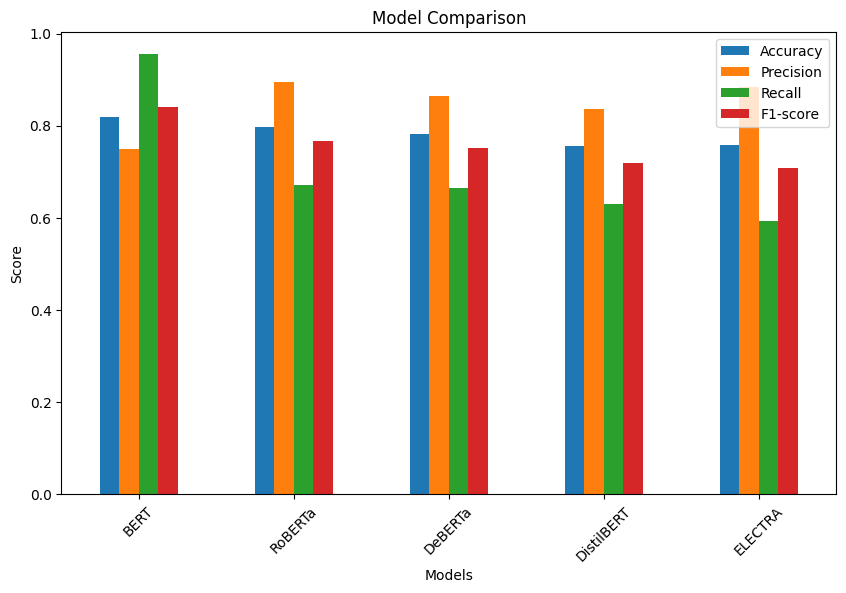

In [ ]:
#Performance Comparison Bar Graph
results_df = pd.DataFrame(results).T
results_df.columns = ["Accuracy", "Precision", "Recall", "F1-score"]

results_df.plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.legend()
plt.show()

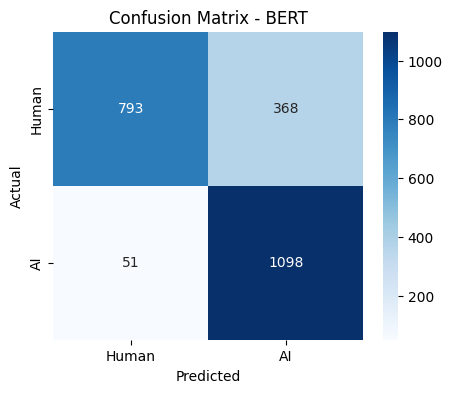

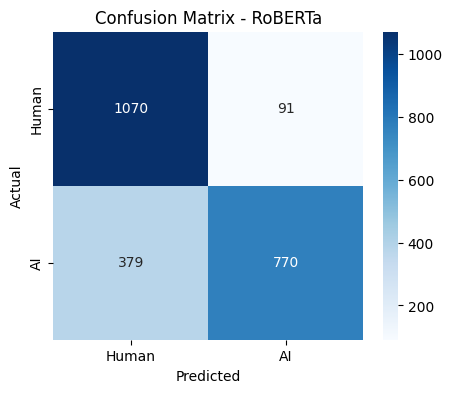

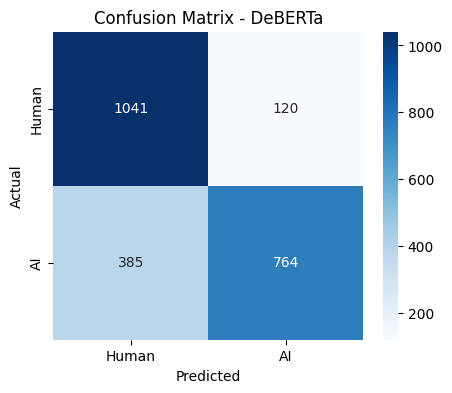

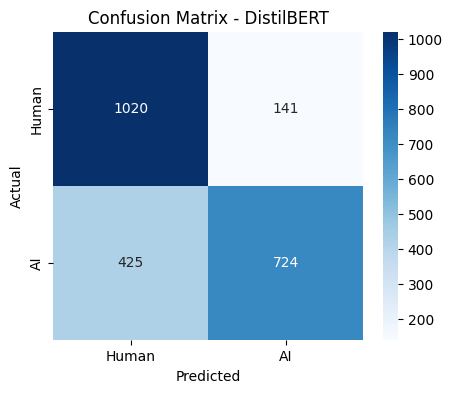

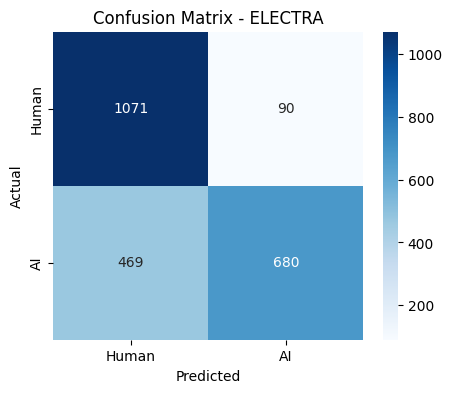

In [ ]:
#Confusion Matrix
for model_name, cm in all_confusion_matrices.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "AI"],
        yticklabels=["Human", "AI"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

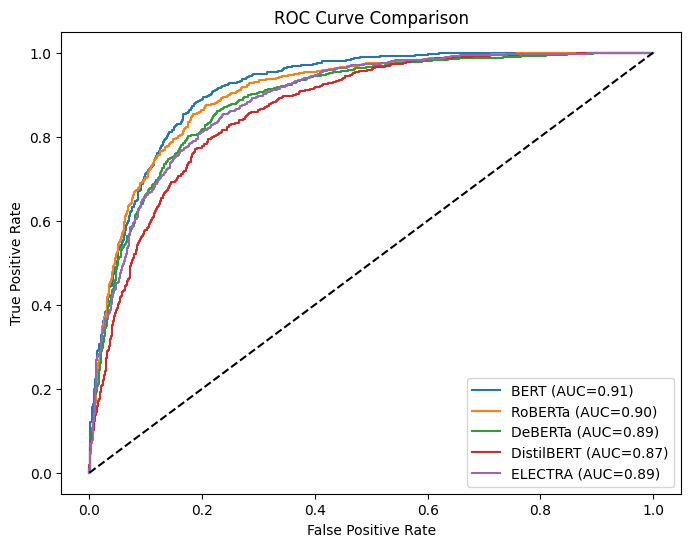

In [ ]:
#ROC Curve Comparison
plt.figure(figsize=(8,6))

for model_name, (fpr, tpr, roc_auc) in all_roc.items():

    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [ ]:
print(results_df)

            Accuracy  Precision    Recall  F1-score
BERT        0.818615   0.748977  0.955614  0.839771
RoBERTa     0.796537   0.894309  0.670148  0.766169
DeBERTa     0.781385   0.864253  0.664926  0.751599
DistilBERT  0.754978   0.836994  0.630113  0.718967
ELECTRA     0.758009   0.883117  0.591819  0.708702


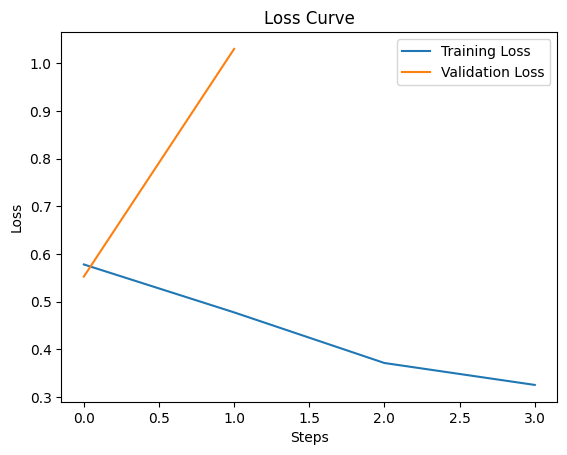

In [ ]:
#Training and Validation Loss Curve
log_history = trainer.state.log_history

train_loss = []
eval_loss = []

for log in log_history:

    if "loss" in log:
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
def test_models(input_text):

    results = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for model_name in trained_models:

        model = trained_models[model_name].to(device)
        tokenizer = trained_tokenizers[model_name]

        inputs = tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )

        # move inputs to same device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        human_prob = probs[0][0].item()
        ai_prob = probs[0][1].item()

        prediction = "Human Written" if human_prob > ai_prob else "AI Generated"

        results.append({
            "Model": model_name,
            "Prediction": prediction,
            "Human Probability": human_prob,
            "AI Probability": ai_prob
        })

    return pd.DataFrame(results)

In [ ]:
input_text = "Cognitive neuroscience has made significant strides, in part due to advancements in neuroimaging techniques, such as Positron Emission Tomography (PET) and functional Magnetic Resonance Imaging (fMRI). One of its primary goals is to comprehend the functioning of the human brain. The dialogue between cognitive neuroscience and psychoanalysis is not a recent development, but in recent times, it has intensified in exploring the intricate relationship between mind and brain, a connection envisioned by Freud over a century ago and emphasized by Nobel Prize winner Kandel (1999), who posited that psychoanalysis still presents the most coherent and intellectually satisfying perspective on the mind, which can aid neurobiologists in planning their research. As of now, neuroscience does not offer a unified, universally accepted, and comprehensive theory of brain-mind function. Nonetheless, it remains an invaluable tool for investigating mind-brain structures and functions in both their physiological and pathological manifestations. While psychoanalysis flourished over a century ago, the initial fruitful dialogue it had with neuroscience has not yet culminated in a complete understanding of the biological underpinnings for all psychoanalytic theoretical frameworks. It is not necessarily the shared objective of psychoanalysts or neuroscientists to achieve this complete integration in their daily work. Although neuroscience and psychoanalysis share a common scientific focus on an in-depth analysis of the mind-brain system's functioning, they employ different investigative tools, methods, and terminologies, necessitating a clear separation and distinction between the two fields, while maintaining an ongoing and fruitful dialogue."

test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,Human Written,0.597901,0.402099
1,RoBERTa,Human Written,0.987208,0.012792
2,DeBERTa,Human Written,0.962683,0.037317
3,DistilBERT,Human Written,0.843457,0.156542
4,ELECTRA,Human Written,0.966221,0.033779


In [ ]:
input_text = "Yesterday I went to the local market with my friend. We bought some vegetables and fruits. The weather was pleasant and the streets were full of people enjoying the evening."

test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,Human Written,0.999389,0.000611
1,RoBERTa,Human Written,0.986871,0.013129
2,DeBERTa,Human Written,0.950114,0.049886
3,DistilBERT,Human Written,0.971285,0.028715
4,ELECTRA,Human Written,0.976521,0.023479


In [ ]:
input_text = "Bali is a Hindu country. Bali is famous for its traditional dances. The dances are inspired by the Hindi faith. Most dances depict the story of good and evil. Watching the dances is a thrilling experience. Some of the notable attractions in Lombok include the magnificent Mount Rinjani, which is an active volcano. It is the second highest volcano in Indonesia. Art is the passion of the people in Bali. Batik paintings and statues are the most popular souvenirs. One will spot artists carving and painting on the streets, especially in Ubud. It is easy to see the charm in each island as a beautiful tourist destination. Majestic views, beautiful culture, white sandy beaches, and blue waters are magnets that attract visitors to the islands every year. Snorkeling and diving in the nearby Gili Islands are magnificent. Fish, starfish, turtles, and a coral reef are abundant in the waters. Bali and Lombok are part of the Indonesian Islands. Bali has some magnificent temples. The most important one is the Mother Temple, Besakih. The people in Lombok are mostly Muslims, with a small percentage of Hindus."
test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,Human Written,0.998488,0.001512
1,RoBERTa,Human Written,0.991541,0.008459
2,DeBERTa,Human Written,0.987997,0.012003
3,DistilBERT,Human Written,0.968563,0.031437
4,ELECTRA,Human Written,0.982137,0.017862


In [ ]:
input_text = "It has been observed that a few students are not attending BCT sessions. All such students are hereby instructed to attend the training session from tomorrow without fail. Otherwise, their guardians will be informed as well. Absentee students may face issues during the upcoming placement drive."
test_models(input_text)

,Model,Prediction,Human Probability,AI Probability
0,BERT,Human Written,0.998476,0.001524
1,RoBERTa,Human Written,0.987256,0.012744
2,DeBERTa,Human Written,0.975701,0.024299
3,DistilBERT,Human Written,0.965007,0.034993
4,ELECTRA,Human Written,0.960330,0.039670


In [ ]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 2. MODEL CONFIG
# ==========================================
MODEL_PATHS = {
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
    "deberta": "microsoft/deberta-base",
    "electra": "google/electra-base-discriminator",
    "distilbert": "distilbert-base-uncased"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 3. LOAD MODELS
# ==========================================
models = {}
tokenizers = {}

print("Loading models...\n")

for name, path in MODEL_PATHS.items():
    print(f"Loading {name}...")
    tokenizers[name] = AutoTokenizer.from_pretrained(path)
    models[name] = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    models[name].eval()

print("\nAll models loaded.\n")

# ==========================================
# 4. ERROR CASES
# ==========================================
error_cases = [
    {
        "text": "The rapid advancement of artificial intelligence has significantly transformed modern industries.",
        "label": "human",
        "case": "Formal Human Writing"
    },
    {
        "text": "AI is like very good tool but sometimes it not working properly and humans also confuse about it.",
        "label": "ai",
        "case": "Poor AI Writing"
    },
    {
        "text": "Yes, that works.",
        "label": "unknown",
        "case": "Short Text"
    },
    {
        "text": "AI is transforming the world. btw I think it’s kinda overrated sometimes lol.",
        "label": "mixed",
        "case": "Hybrid Text"
    },
    {
        "text": "Healthcare is being completely transformed due to artificial intelligence.",
        "label": "ai",
        "case": "Paraphrased AI"
    },
    {
        "text": "The convolutional neural network achieved 92% accuracy on the CIFAR-10 dataset.",
        "label": "human",
        "case": "Technical Text"
    }
]

# ==========================================
# 5. PREDICTION FUNCTION
# ==========================================
def predict(text, model, tokenizer):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy().tolist()[0]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def get_error_type(true, pred):
    if true in ["unknown", "mixed"]:
        return "Ambiguous"
    if true == "human" and pred == "ai":
        return "False Positive"
    if true == "ai" and pred == "human":
        return "False Negative"
    return "Correct"

def get_status(true, pred):
    if true in ["unknown", "mixed"]:
        return "Ambiguous"
    return "Correct" if true == pred else "Incorrect"

# ==========================================
# 7. RUN ANALYSIS
# ==========================================
results = []

for case in error_cases:
    for model_name in models:
        pred, probs = predict(case["text"], models[model_name], tokenizers[model_name])

        pred_label = "ai" if pred == 1 else "human"
        confidence = max(probs)

        results.append({
            "Case": case["case"],
            "Model": model_name.upper(),
            "Expected": case["label"],
            "Predicted": pred_label,
            "Confidence": round(confidence, 3),
            "Status": get_status(case["label"], pred_label),
            "Error Type": get_error_type(case["label"], pred_label)
        })

# ==========================================
# 8. DISPLAY RESULTS
# ==========================================
df = pd.DataFrame(results)
df = df.sort_values(by=["Case", "Model"])

print("\nError Analysis Results:\n")
print(df.to_string(index=False))

# ==========================================
# 9. SAVE FILE
# ==========================================
df.to_csv("error_analysis_clean.csv", index=False)

print("\nResults saved as 'error_analysis_clean.csv'")

Loading models...

Loading bert...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading roberta...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Loading distilbert...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



All models loaded.


Error Analysis Results:

                Case      Model Expected Predicted  Confidence    Status     Error Type
Formal Human Writing       BERT    human     human       0.589   Correct        Correct
Formal Human Writing    DEBERTA    human     human       0.570   Correct        Correct
Formal Human Writing DISTILBERT    human        ai       0.530 Incorrect False Positive
Formal Human Writing    ELECTRA    human        ai       0.529 Incorrect False Positive
Formal Human Writing    ROBERTA    human     human       0.501   Correct        Correct
         Hybrid Text       BERT    mixed     human       0.578 Ambiguous      Ambiguous
         Hybrid Text    DEBERTA    mixed     human       0.569 Ambiguous      Ambiguous
         Hybrid Text DISTILBERT    mixed        ai       0.516 Ambiguous      Ambiguous
         Hybrid Text    ELECTRA    mixed        ai       0.502 Ambiguous      Ambiguous
         Hybrid Text    ROBERTA    mixed     human       0.503 Ambiguous 

In [ ]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 2. LOAD YOUR TEST DATA
# ==========================================
# Replace with your file
df = pd.read_csv("Dataset_preprocess_final.csv" ,encoding="latin" )

# Check columns
print(df.head())

# ==========================================
# 3. MODEL CONFIG (USE YOUR TRAINED PATH IF AVAILABLE)
# ==========================================
MODEL_PATHS = {
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
    "deberta": "microsoft/deberta-base",
    "electra": "google/electra-base-discriminator",
    "distilbert": "distilbert-base-uncased"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 4. LOAD MODELS
# ==========================================
models = {}
tokenizers = {}

print("Loading models...\n")

for name, path in MODEL_PATHS.items():
    print(f"Loading {name}...")
    tokenizers[name] = AutoTokenizer.from_pretrained(path)
    models[name] = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    models[name].eval()

print("\nAll models loaded.\n")

# ==========================================
# 5. PREDICTION FUNCTION
# ==========================================
def predict(text, model, tokenizer):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy().tolist()[0]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def get_error_type(true, pred):
    if true == 0 and pred == 1:
        return "False Positive"
    if true == 1 and pred == 0:
        return "False Negative"
    return "Correct"

def label_to_text(label):
    return "ai" if label == 1 else "human"

# ==========================================
# 7. RUN ON TEST DATA
# ==========================================
results = []

for i, row in df.iterrows():
    text = str(row["text"])
    true_label = int(row["label_name"])

    for model_name in models:
        pred, probs = predict(text, models[model_name], tokenizers[model_name])

        results.append({
            "Text": text[:100],  # shorten for readability
            "Model": model_name.upper(),
            "Actual": label_to_text(true_label),
            "Predicted": label_to_text(pred),
            "Confidence": round(max(probs), 3),
            "Error Type": get_error_type(true_label, pred)
        })

# ==========================================
# 8. CREATE DATAFRAME
# ==========================================
df_results = pd.DataFrame(results)

# ==========================================
# 9. FILTER ONLY ERRORS
# ==========================================
df_errors = df_results[df_results["Error Type"] != "Correct"]

print("\nSample Error Cases:\n")
print(df_errors.head(20).to_string(index=False))

# ==========================================
# 10. SAVE FILES
# ==========================================
df_results.to_csv("all_predictions.csv", index=False)
df_errors.to_csv("error_cases_only.csv", index=False)

print("\nSaved:")
print("- all_predictions.csv (all outputs)")
print("- error_cases_only.csv (only errors)")

                                                text       source  \
0  Cop Accused Of BrutalityA 9th Time\n\nby Meli...  openwebtext   
1  I last visited McDowell County, West Virginia,...  openwebtext   
2  In grammar, a future tense (abbreviated FUT) i...  openwebtext   
3  Do you remember the girl that made you feel th...  openwebtext   
4  The OS and the disk\n\n1: The client sends a w...  openwebtext   

      label_name  generated  
0  human-written          1  
1  human-written          1  
2  human-written          1  
3  human-written          1  
4  human-written          1  
Loading models...

Loading bert...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading roberta...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading distilbert...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



All models loaded.



ValueError: invalid literal for int() with base 10: 'human-written'

In [ ]:
# ==========================================
# 1. IMPORTS
# ==========================================
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv("Dataset_preprocess_final.csv" ,encoding="latin|")

# Convert labels: human -> 1, ai -> 0
def convert_label(label):
    label = str(label).lower()
    if "human" in label:
        return 1
    elif "ai" in label:
        return 0
    else:
        return -1  # ignore unknown

df["label"] = df["label_name"].apply(convert_label)

# Remove unknown rows
df = df[df["label"] != -1]

# OPTIONAL: run small sample first (remove later)
df = df.head(100)

print("Dataset loaded. Total samples:", len(df))

# ==========================================
# 3. MODEL CONFIG
# ==========================================
MODEL_PATHS = {
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
    "deberta": "microsoft/deberta-base",
    "electra": "google/electra-base-discriminator",
    "distilbert": "distilbert-base-uncased"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ==========================================
# 4. LOAD MODELS
# ==========================================
models = {}
tokenizers = {}

print("\nLoading models...\n")

for name, path in MODEL_PATHS.items():
    print(f"Loading {name}...")
    tokenizers[name] = AutoTokenizer.from_pretrained(path)
    models[name] = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    models[name].eval()

print("\nAll models loaded.\n")

# ==========================================
# 5. PREDICTION FUNCTION
# ==========================================
def predict(text, model, tokenizer):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy()[0]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def label_to_text(label):
    return "human" if label == 1 else "ai"

def get_error_type(true, pred):
    if true == 1 and pred == 0:
        return "False Negative"   # human predicted as ai
    if true == 0 and pred == 1:
        return "False Positive"   # ai predicted as human
    return "Correct"

# ==========================================
# 7. RUN ANALYSIS
# ==========================================
results = []

for i, row in df.iterrows():
    if i % 20 == 0:
        print(f"Processing {i}/{len(df)}")

    text = str(row["text"])
    true_label = int(row["label"])

    for model_name in models:
        pred, probs = predict(text, models[model_name], tokenizers[model_name])

        results.append({
            "Text": text[:100],
            "Model": model_name.upper(),
            "Actual": label_to_text(true_label),
            "Predicted": label_to_text(pred),
            "Confidence": round(max(probs), 3),
            "Error Type": get_error_type(true_label, pred)
        })

# ==========================================
# 8. CREATE DATAFRAME
# ==========================================
df_results = pd.DataFrame(results)

# Filter only errors
df_errors = df_results[df_results["Error Type"] != "Correct"]

# ==========================================
# 9. DISPLAY OUTPUT
# ==========================================
print("\nSample Error Cases:\n")
print(df_errors.head(20).to_string(index=False))

# ==========================================
# 10. SAVE FILES
# ==========================================
df_results.to_csv("all_predictions.csv", index=False)
df_errors.to_csv("error_cases_only.csv", index=False)

print("\nSaved files:")
print("all_predictions.csv")
print("error_cases_only.csv")

Dataset loaded. Total samples: 100
Using device: cuda

Loading models...

Loading bert...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading roberta...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Loading distilbert...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



All models loaded.

Processing 0/100
Processing 20/100
Processing 40/100
Processing 60/100
Processing 80/100

Sample Error Cases:

                                                                                                    Text   Model Actual Predicted  Confidence     Error Type
Cop Accused Of BrutalityA 9th Time\n\nby Melinda Tuhus & Thomas MacMillan | Jan 7, 2011 3:02 pm\n\n(46) ROBERTA  human        ai       0.547 False Negative
Cop Accused Of BrutalityA 9th Time\n\nby Melinda Tuhus & Thomas MacMillan | Jan 7, 2011 3:02 pm\n\n(46) DEBERTA  human        ai       0.500 False Negative
Cop Accused Of BrutalityA 9th Time\n\nby Melinda Tuhus & Thomas MacMillan | Jan 7, 2011 3:02 pm\n\n(46) ELECTRA  human        ai       0.533 False Negative
    I last visited McDowell County, West Virginia, over 40 years ago. Even then, I was already an outsid ROBERTA  human        ai       0.549 False Negative
    I last visited McDowell County, West Virginia, over 40 years ago. Even then, I 

In [ ]:
# ==========================================
# ERROR COUNT PER MODEL
# ==========================================

# Total predictions per model
total_counts = df_results.groupby("Model").size()

# Error counts per model
error_counts = df_results[df_results["Error Type"] != "Correct"].groupby("Model").size()

# Combine into one table
summary = pd.DataFrame({
    "Total Samples": total_counts,
    "Total Errors": error_counts
}).fillna(0)

# Convert errors to int
summary["Total Errors"] = summary["Total Errors"].astype(int)

# Calculate error percentage
summary["Error Rate (%)"] = (summary["Total Errors"] / summary["Total Samples"]) * 100

# Sort by error rate (optional)
summary = summary.sort_values(by="Error Rate (%)", ascending=False)

# ==========================================
# DISPLAY RESULT
# ==========================================
print("\nModel Error Summary:\n")
print(summary.to_string())

# ==========================================
# SAVE FILE
# ==========================================
summary.to_csv("model_error_summary.csv")

print("\nSaved as model_error_summary.csv")


Model Error Summary:

            Total Samples  Total Errors  Error Rate (%)
Model                                                  
ROBERTA               100           100           100.0
ELECTRA               100           100           100.0
DEBERTA               100            49            49.0
BERT                  100             0             0.0
DISTILBERT            100             0             0.0

Saved as model_error_summary.csv


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
from google.colab import files
files.download("model_error_summary.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("error_cases_only.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("all_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>